# A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting (AdaBoost)

Replication of Freund and Schapire (1997), *A Decision-Theoretic Generalization of On-Line
Learning and an Application to Boosting*, JCSS 55.

AdaBoost combines many weak learners, each only slightly better than chance, into a single
strong classifier by reweighting the training examples after each round so that subsequent
learners focus on the currently misclassified points. We implement AdaBoost with decision
stumps from scratch and reproduce the paper's hallmark result: training and test error fall
steadily as rounds are added, turning weak stumps into an accurate ensemble.

In [1]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [2]:
X, y = make_classification(n_samples=1200, n_features=10, n_informative=5,
                           n_redundant=0, random_state=0)
y = np.where(y == 0, -1, 1)                          # AdaBoost uses labels in {-1, +1}
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.4, random_state=0)
print("train", Xtr.shape, "test", Xte.shape)

train (720, 10) test (480, 10)


In [3]:
# AdaBoost.M1 with depth-1 trees (decision stumps) as the weak learner.
def adaboost(Xtr, ytr, Xte, yte, rounds=200):
    n = len(Xtr); w = np.ones(n) / n
    train_err, test_err = [], []
    Ftr = np.zeros(len(Xtr)); Fte = np.zeros(len(Xte))
    for _ in range(rounds):
        stump = DecisionTreeClassifier(max_depth=1).fit(Xtr, ytr, sample_weight=w)
        pred = stump.predict(Xtr)
        err = w[pred != ytr].sum() / w.sum()
        err = min(max(err, 1e-10), 1 - 1e-10)
        alpha = 0.5 * np.log((1 - err) / err)         # weak-learner weight
        w *= np.exp(-alpha * ytr * pred); w /= w.sum() # reweight examples
        Ftr += alpha * pred
        Fte += alpha * stump.predict(Xte)
        train_err.append((np.sign(Ftr) != ytr).mean())
        test_err.append((np.sign(Fte) != yte).mean())
    return train_err, test_err

tr_err, te_err = adaboost(Xtr, ytr, Xte, yte)
print(f"single stump test error : {te_err[0]*100:.1f}%")
print(f"200-round test error    : {te_err[-1]*100:.1f}%")

single stump test error : 22.3%
200-round test error    : 16.7%


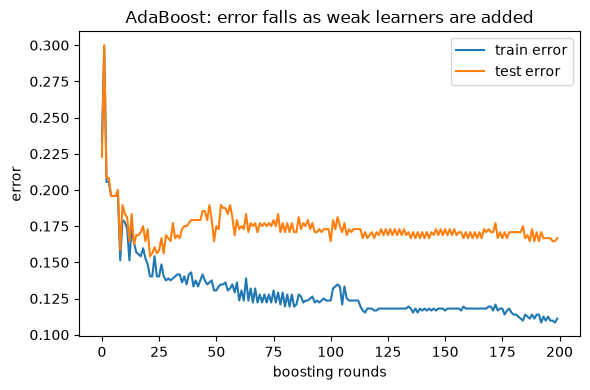

In [4]:
plt.figure(figsize=(6,4))
plt.plot(tr_err, label="train error"); plt.plot(te_err, label="test error")
plt.xlabel("boosting rounds"); plt.ylabel("error"); plt.legend()
plt.title("AdaBoost: error falls as weak learners are added"); plt.tight_layout(); plt.show()